# [AI] 스프린트 미션3 소개
이번 미션에서는 지금까지 배운 지도 학습 알고리즘을 총동원해서, 전 세계에서 가장 유명한 머신러닝 입문 대회인 캐글 타이타닉 대회에 직접 참가합니다.

1912년, 타이타닉호는 첫 항해 중 빙산과 충돌해 침몰했고 승객 2,224명 중 1,502명이 사망했습니다. 생존에는 운도 작용했지만, 데이터를 보면 어떤 집단이 더 많이 살아남았는지 뚜렷한 패턴이 있습니다. 여러분은 승객 정보를 바탕으로 누가 생존했는지(Survived) 예측하는 이진 분류 모델을 만들어, 실제 캐글 리더보드에 제출해 보세요.

이 미션은 데이터를 분석하고 인사이트를 뽑아내는 것보다, 전처리부터 모델 튜닝까지 지도 학습 파이프라인을 얼마나 잘 구축하는지를 확인하는 데 목적이 있습니다. 로지스틱 회귀, 결정트리, 앙상블 기법을 모두 실험해 보고, 어떤 모델과 설정이 가장 좋은 성능을 내는지 직접 확인해 보세요.

In [ ]:
# import kagglehub

# #Download lastest version
# path = kagglehub.competition_download('titanic')

# print("Path to competition file:", path)


c:\Users\dsbang\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


100%|██████████| 34.1k/34.1k [00:00<00:00, 14.3MB/s]

Extracting files...
Path to competition file: C:\Users\dsbang\.cache\kagglehub\competitions\titanic


In [184]:
PATH = 'C:/Users/dsbang/.cache/kagglehub/competitions/titanic' 

import pandas as pd
import matplotlib.pyplot as plt

raw_train_df = pd.read_csv(PATH +'/train.csv')
test_df = pd.read_csv(PATH + '/test.csv')

display(raw_train_df)
display(test_df)
#target_df = train_df['Survived']


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
413,1305,3,"Spector, Mr. Woolf",male,NaN,0,0,A.5. 3236,8.0500,NaN,S
414,1306,1,"Oliva y Ocana, Dona. Fermina",female,39.0,0,0,PC 17758,108.9000,C105,C
415,1307,3,"Saether, Mr. Simon Sivertsen",male,38.5,0,0,SOTON/O.Q. 3101262,7.2500,NaN,S
416,1308,3,"Ware, Mr. Frederick",male,NaN,0,0,359309,8.0500,NaN,S


# 데이터 소개
타이타닉 승객 891명의 정보가 담긴 train 데이터와, 생존 여부를 예측해야 하는 승객 418명의 test 데이터가 제공됩니다.

## 데이터 정의서
|컬럼명 |데이터 타입 | 설명 |
|:-------|:---------:|:---------------|
|PassengerId | int | 승객 고유번호, 제출 파일의 키로 사용됩니다.|
|Survived | int | 타깃 변수. 생존 여부(0:사망, 1:생존). train 데이터에만 존재하고, 예측 대상입니다.|
|Pclass | int | 티켓 등급(1: 1등석, 2: 2등석, 3:3등석). 사회경제적 지위를 대신 보여주는 변수입니다. |
|Name |	object(str) |	승객 이름. Mr, Mrs, Miss, Master 같은 호칭이 포함되어 있습니다.|
|Sex | object	| 성별. |
|Age	|float	|나이. 1살 미만은 소수점으로 표기됩니다.
|SibSp	|int	|함께 탑승한 형제자매와 배우자 수. # of siblings / spouses aboard the Titanic
|Parch	|int	|함께 탑승한 부모와 자녀 수. # of parents / children aboard the Titanic
|Ticket	|object	|티켓 번호.
|Fare	|float	|운임.
|Cabin	|object	|객실 번호.
|Embarked	|object	|탑승 항구(C: Cherbourg, Q: Queenstown, S: Southampton).

In [185]:
display(raw_train_df.head() )
display(test_df.head()) 
TARGET='Survived'
FEATURES=['Pclass','Sex','Age','SibSp','Parch','Fare','Cabin','Embarked']

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


## 1. 데이터 분석
- 중복행, 컬럼별 결측치 비율을 확인 

In [186]:

df = raw_train_df.copy()

print("=" * 60)
print("1. 데이터 기본 구조 및 결측치 요약")
print("=" * 60)
print(f"- 데이터 크기: {df.shape[0]}행, {df.shape[1]}열")
print(f"- 중복 행 수: {df.duplicated().sum()}개")
print(f"- 결측 총갯수:  {df.isnull().sum().sum()}개  ")
print(f"- 결측 값있는 행수:  { df.isnull().any(axis=1).sum() }행  ")
print(f"- 결측 행의 전체 비율:  {( df.isnull().any(axis=1).sum() / len(df)).round(4):.1%}  ")

print(f"- 입력 Feasture의 결측 갯수: {df[FEATURES].isnull().sum().sum()}개")
print(f"- 입력 Feasture의 결측 행수: {df[FEATURES].isnull().any(axis=1).sum()}행")    
print(f"- 입력 Feasture의 결측 행의 전체중 비율: {df[FEATURES].isnull().any(axis=1).sum() / len(df):.1%}")  
# 1. 결측값이 있는 컬럼 확인
print("== 컬럼별 결측 수량 확인: ")
display(pd.DataFrame(df.isnull().sum(), columns=['결측수량']))

# 2. 결측값이 있는 각 컬럼별 정보 출력
null_cols = df.isnull().sum()
missing_val_cols = null_cols[null_cols > 0].index

print("=== 결측값이 있는 컬럼별 상세 정보 ===\n")
for col in missing_val_cols:
    print(f" 컬럼명: {col}")
    print(f" 총행수: {len(df[col])}")
    print(f" 결측값 개수: {null_cols[col]}개")
    print(f" 결측값 비율: {null_cols[col]/len(df[col]):.2%}")
    print(f" 최빈값 : { df[col].mode()[0] }")

    if df[col].dtype != 'str':
        print(f" Min값: {df[col].min(numeric_only=True):.2f}")
        print(f" Max값: {df[col].max(numeric_only=True):.2f}")
        print(f" Mean값: {df[col].mean(numeric_only=True):.2f}")
        print(f" Median값: {df[col].median(numeric_only=True):.2f}")    
        print(f" Std값: {df[col].std():.2f}")   


    # dropna=True 옵션으로 결측치를 제외한 유니크 값을 가져옵니다.
    unique_values = df[col].dropna().unique()
    unique_count = df[col].dropna().nunique()

    print(f" 고유값 개수 (결측치 제외): {unique_count}개")
    print(f" 고유값 종류: {unique_values}")
    print(f" 값별 수량: {df[col].value_counts()}")
    print("-" * 40)
    print()

1. 데이터 기본 구조 및 결측치 요약
- 데이터 크기: 891행, 12열
- 중복 행 수: 0개
- 결측 총갯수:  866개  
- 결측 값있는 행수:  708행  
- 결측 행의 전체 비율:  79.5%  
- 입력 Feasture의 결측 갯수: 866개
- 입력 Feasture의 결측 행수: 708행
- 입력 Feasture의 결측 행의 전체중 비율: 79.5%
== 컬럼별 결측 수량 확인: 


,결측수량
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


=== 결측값이 있는 컬럼별 상세 정보 ===

 컬럼명: Age
 총행수: 891
 결측값 개수: 177개
 결측값 비율: 19.87%
 최빈값 : 24.0
 Min값: 0.42
 Max값: 80.00
 Mean값: 29.70
 Median값: 28.00
 Std값: 14.53
 고유값 개수 (결측치 제외): 88개
 고유값 종류: [22.   38.   26.   35.   54.    2.   27.   14.    4.   58.   20.   39.
 55.   31.   34.   15.   28.    8.   19.   40.   66.   42.   21.   18.
  3.    7.   49.   29.   65.   28.5   5.   11.   45.   17.   32.   16.
 25.    0.83 30.   33.   23.   24.   46.   59.   71.   37.   47.   14.5
 70.5  32.5  12.    9.   36.5  51.   55.5  40.5  44.    1.   61.   56.
 50.   36.   45.5  20.5  62.   41.   52.   63.   23.5   0.92 43.   60.
 10.   64.   13.   48.    0.75 53.   57.   80.   70.   24.5   6.    0.67
 30.5   0.42 34.5  74.  ]
 값별 수량: Age
24.00    30
22.00    27
18.00    26
28.00    25
19.00    25
         ..
24.50     1
0.67      1
0.42      1
34.50     1
74.00     1
Name: count, Length: 88, dtype: int64
----------------------------------------

 컬럼명: Cabin
 총행수: 891
 결측값 개수: 687개
 결측값 비율: 77.10%
 최빈값 : B96

## -. 컬럼별 처리방법 결정
### 중요하지 않은 변수 제외 
####  사유: 유니크한 개별 값
- PassergerID, Name, Ticket, Cabin

### 결측컬럼별 처리 결정 내용
- Age : 약 20%의 결측, 연령 기준을 볼수 있는 유일한 속성,  최빈값이 24, 평균값 29.7, 중앙값 28 으로 평균값으로 채우기로 결정
- Cabin : 약 77%의 결측, 객실번호는 유니크한 개별값이나 객실번호의 첫 글자는 배의 구조를 판단할 수 있는 정보로 겹치지 않는 특정한 값으로 'X'으로 처리후, 첫 글자만 변수로 사용
- Embarked: 약 0.22%의 결측, 결측 비율이 크지 않이 무시하고 비중이 큰 값으로 치환하기로 결정. 'S', 'C', 'Q' 개의 값이 존재하고 S가 72%로 초빈값



## 2 피쳐 엔지니어링
- Name 에서 호칭(Mr, Mrs, Miss, Master  등)을 추출 후 title 컬럼에 저장
```
import re
df['Title'] = df['Name'].str.extract(r',\s*([A-Za-z]+)\.')
df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})
print(df['title'].value_counts())
```
- SibSp 와 Parch 합쳐 가족 규모(FamilySize)변수로 사용 (본인 기본 +1)
```
df['FamilySize'] =  df['SibSp'] + df['Parch'] +1 
```
- Cabin 의 첫 글자(갑판) 추출하여 배구조정보 변수로 사용 --> NaN 값은 X로 처리(기존에 없는 값)
```
df['DeckofShip'] = df['Cabin'].fillna('X').astype(str).str[0:1]
print(df['DeckofShip'].value_counts())

```
- Age 결측값: 평균으로 통일
```
df['Age'] = df['Age'].fillna(df['Age'].mean(numeric_only=True).round(2))
```
- Embarked 결측값 : 2%로 가장 많은 'S'값으로 처리
```
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
print(df['Embarked'].value_counts())
```
- 사용하지 않을 컬럼
'Name','SibSp','Parch','Ticket','Cabin'

In [187]:
# ## 2 피쳐 엔지니어링 실행
# - Name 에서 호칭(Mr, Mrs, Miss, Master  등)을 추출 후 title 컬럼에 저장
# ```
import re
df['Title'] = df['Name'].str.extract(r',\s*([A-Za-z]+)\.')
df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})
print(df['Title'].value_counts())
# ```
# - SibSp 와 Parch 합쳐 가족 규모(FamilySize)변수로 사용 (본인 기본 +1)
# ```
df['FamilySize'] =  df['SibSp'] + df['Parch'] +1 
# ```
# - Cabin 의 첫 글자(갑판) 추출하여 배구조정보 변수로 사용 --> NaN 값은 X로 처리(기존에 없는 값)
# ```
df['DeckofShip'] = df['Cabin'].fillna('X').astype(str).str[0:1]
print(df['DeckofShip'].value_counts())

# ```
# - Age 결측값: 평균으로 통일
# ```
df['Age'] = df['Age'].fillna(df['Age'].mean(numeric_only=True).round(2))
# ```
# - Embarked 결측값 : 2%로 가장 많은 'S'값으로 처리
# ```
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])
print(df['Embarked'].value_counts())
df 

Title
Mr          517
Miss        185
Mrs         126
Master       40
Dr            7
Rev           6
Major         2
Col           2
Don           1
Lady          1
Sir           1
Capt          1
Jonkheer      1
Name: count, dtype: int64
DeckofShip
X    687
C     59
B     47
D     33
E     32
A     15
F     13
G      4
T      1
Name: count, dtype: int64
Embarked
S    646
C    168
Q     77
Name: count, dtype: int64


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Title,FamilySize,DeckofShip
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,Mr,2,X
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,Mrs,2,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,Miss,1,X
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,Mrs,2,C
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,Mr,1,X
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,Rev,1,X
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,Miss,1,B
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,29.7,1,2,W./C. 6607,23.4500,NaN,S,Miss,4,X
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,Mr,1,C


In [188]:
##보기 편하게 정리
data_df = df.drop(['Name','SibSp','Parch','Ticket','Cabin'], axis=1)
data_df

,PassengerId,Survived,Pclass,Sex,Age,Fare,Embarked,Title,FamilySize,DeckofShip
0,1,0,3,male,22.0,7.2500,S,Mr,2,X
1,2,1,1,female,38.0,71.2833,C,Mrs,2,C
2,3,1,3,female,26.0,7.9250,S,Miss,1,X
3,4,1,1,female,35.0,53.1000,S,Mrs,2,C
4,5,0,3,male,35.0,8.0500,S,Mr,1,X
...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,male,27.0,13.0000,S,Rev,1,X
887,888,1,1,female,19.0,30.0000,S,Miss,1,B
888,889,0,3,female,29.7,23.4500,S,Miss,4,X
889,890,1,1,male,26.0,30.0000,C,Mr,1,C


## 3. Features 분석

In [189]:
## 사용할 Features 정리
TARGET = 'Survived'
FEATURES = ['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'Title', 'FamilySize', 'DeckofShip']


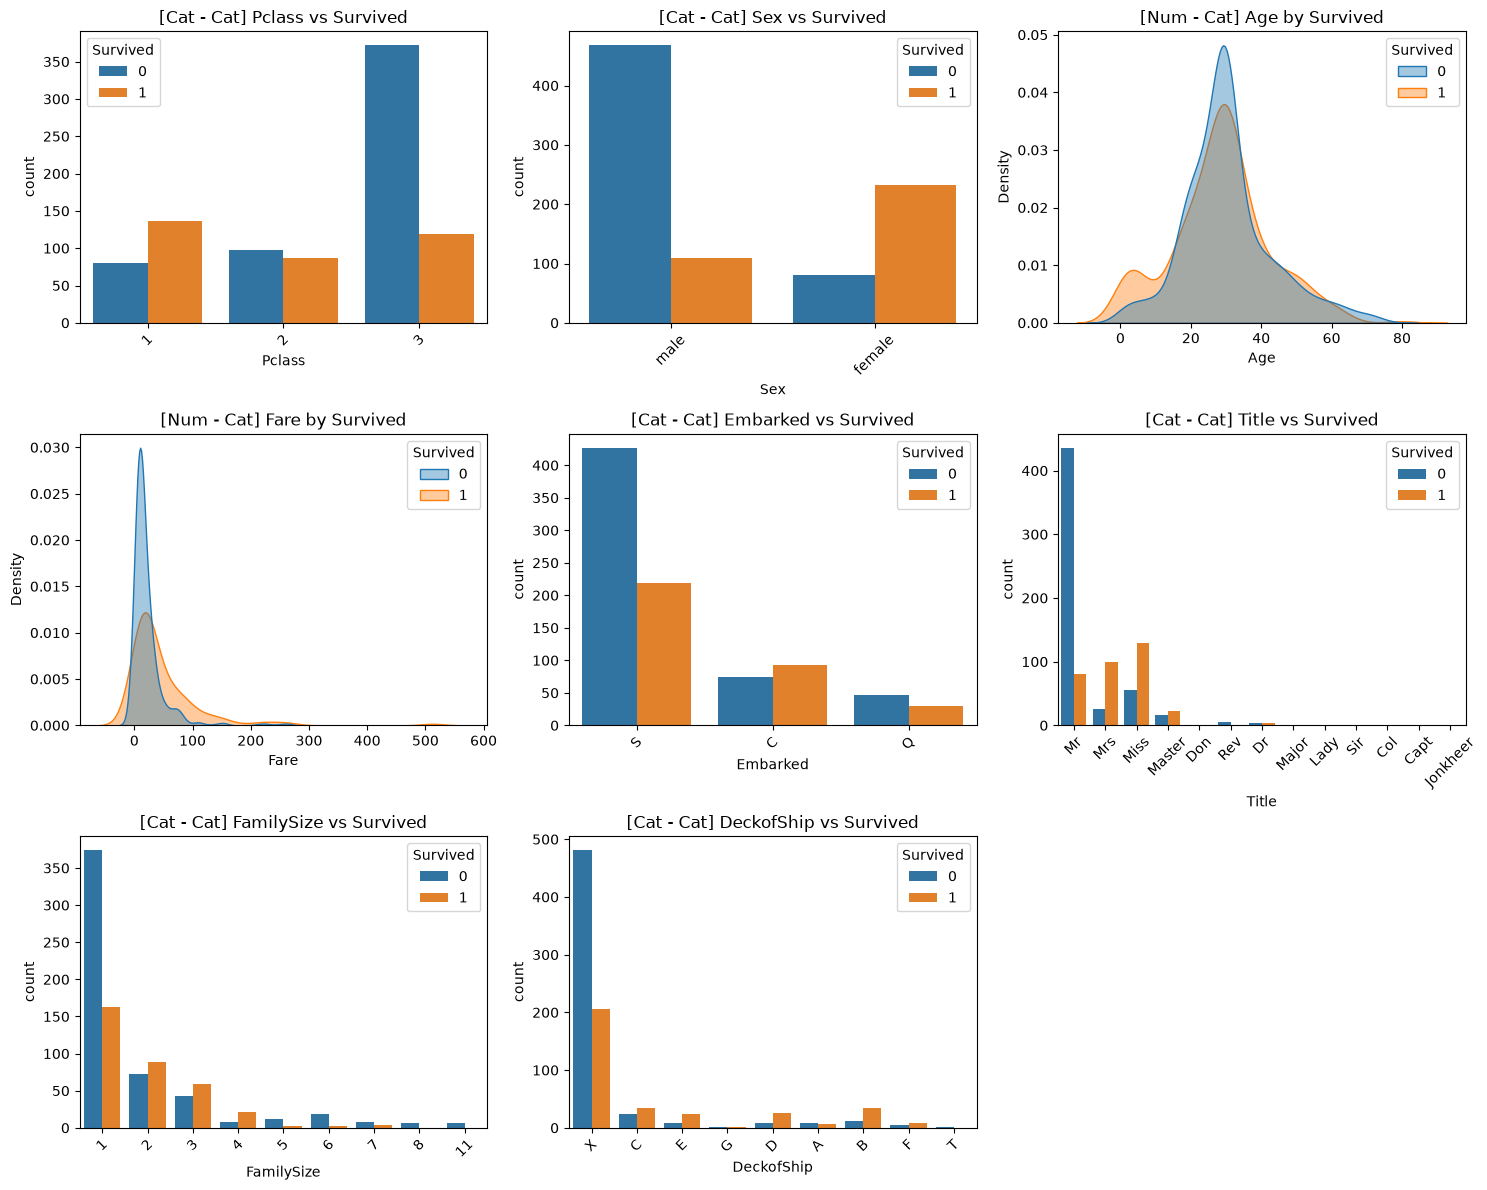

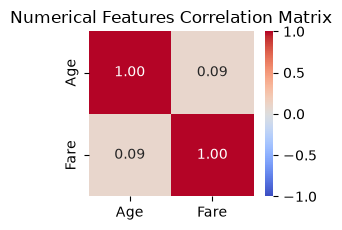

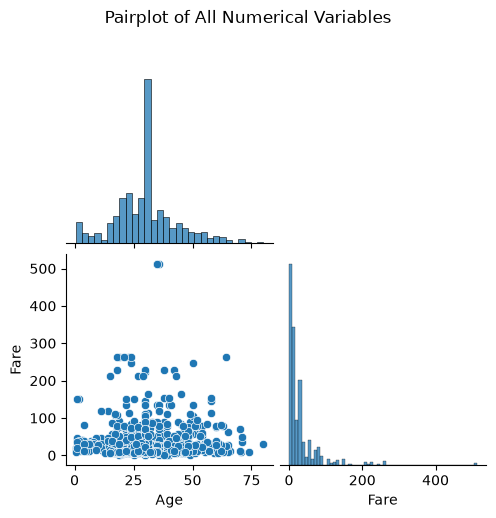

* Tip: Mutual_Info가 높을수록 중요한 변수이며, VIF가 10 이상이면 다중공선성을 의심하세요.


,Feature,Mutual_Info,Pearson_Corr_Abs,VIF_Score
0,Title,0.153988,0.046520,1.062702
1,Fare,0.140576,0.257307,1.701868
2,Sex,0.133217,0.543351,1.093848
3,Pclass,0.062738,0.338481,2.686234
4,DeckofShip,0.057939,0.301116,2.374386
5,Age,0.034869,0.069811,1.252611
6,FamilySize,0.013179,0.016639,1.224800
7,Embarked,0.004097,0.167675,1.089766


In [191]:
#########################################################################
## Features 데이터 분석 
#########################################################################
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression
from statsmodels.stats.outliers_influence import variance_inflation_factor

# ==========================================
# 타깃 및 변수 상관 그래프 함수
# ==========================================
def plot_feature_relationships(data_df, target_column, feature_columns, max_cols=3, cat_threshold=10, show_pairplot=True):
    """
    미전처리 데이터프레임의 변수 및 타깃 간 관계를 자동 판단하여 시각화하는 함수
    
    Parameters:
    - data_df (pd.DataFrame): 분석할 데이터프레임
    - target_column (str): 타깃 컬럼명
    - feature_columns (list): 분석할 피처 컬럼명 리스트
    - max_cols (int): 한 행에 배치할 최대 서브플롯 개수 (기본값: 3)
    - cat_threshold (int): 정수형 데이터를 범주형으로 판단할 유니크 값 기준 개수
    - show_pairplot (bool): 수치형 변수 간 산점도 행렬(Pairplot) 출력 여부 (기본값: True)
    """
    df = data_df.copy()
    
    # 1. 범주형 데이터 여부 자동 판단 함수
    def is_categorical(series):
        if series.dtype == 'str' or series.dtype == 'object' or series.dtype.name in ['category', 'bool']:
            return True
        if series.nunique() <= cat_threshold and not np.issubdtype(series.dtype, np.floating):
            return True
        return False

    is_target_cat = is_categorical(df[target_column])
    num_features = len(feature_columns)
    
    # 2. 동적 서브플롯 그리드 계산
    n_cols = min(max_cols, num_features)
    n_rows = (num_features + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 4 * n_rows))
    if num_features == 1:
        axes = np.array([axes])
    axes = axes.flatten()
    
    # 3. 각 피처와 타깃 간의 관계 시각화
    for i, col in enumerate(feature_columns):
        ax = axes[i]
        is_feature_cat = is_categorical(df[col])
        
        if not is_target_cat and not is_feature_cat:
            sns.regplot(data=df, x=col, y=target_column, ax=ax, 
                        scatter_kws={'alpha': 0.5}, line_kws={'color': 'red'})
            ax.set_title(f'[Num - Num] {col} vs {target_column}')
            
        elif not is_target_cat and is_feature_cat:
            sns.boxplot(data=df, x=col, y=target_column, ax=ax)
            ax.set_title(f'[Cat - Num] {col} vs {target_column}')
            ax.tick_params(axis='x', rotation=45)
            
        elif is_target_cat and not is_feature_cat:
            sns.kdeplot(data=df, x=col, hue=target_column, ax=ax, fill=True, alpha=0.4, common_norm=False)
            ax.set_title(f'[Num - Cat] {col} by {target_column}')
            
        else:
            sns.countplot(data=df, x=col, hue=target_column, ax=ax)
            ax.set_title(f'[Cat - Cat] {col} vs {target_column}')
            ax.tick_params(axis='x', rotation=45)

    for j in range(num_features, len(axes)):
        fig.delaxes(axes[j])
        
    plt.tight_layout()
    plt.show()

    # 4. 수치형 피처 간 상관관계 매트릭스 (Heatmap)
    num_cols = [c for c in feature_columns if not is_categorical(df[c])]
    if len(num_cols) > 1:
        plt.figure(figsize=(min(12, len(num_cols) * 1.5), min(10, len(num_cols) * 1.2)))
        corr = df[num_cols].corr()
        sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, square=True)
        plt.title('Numerical Features Correlation Matrix')
        plt.tight_layout()
        plt.show()

    # 5. 수치형 변수(피처 + 타깃) 간의 산점도 행렬(Pairplot)
    if show_pairplot:
        all_num_cols = [c for c in feature_columns + [target_column] if not is_categorical(df[c])]
        if len(all_num_cols) > 1:
            # corner=True 옵션으로 중복 대칭 부분(상단) 제거하여 깔끔하게 표시
            sns.pairplot(df[all_num_cols], corner=True)
            plt.suptitle('Pairplot of All Numerical Variables', y=1.02)
            plt.show()

# ==========================================
# 변수 상관 분석 함수 
# ==========================================
def analyze_features(df, feature_cols, target_col, is_classification=True):
    """
    개선된 피처 분석 함수:
    - 수치형 피처 중심의 VIF 및 Mutual Information(상호 정보량) 기반 통합 분석 리포트 제공
    """
    df_analyzed = df.copy()
    
    # 1. 타겟 변수 안전 인코딩
    if is_classification and (df_analyzed[target_col].dtype in ['object', 'string', 'category']):
        le = LabelEncoder()
        df_analyzed[target_col] = le.fit_transform(df_analyzed[target_col].astype(str))
        
    # 범주형(문자열) 피처들을 숫자로 안전하게 인코딩 (MI 계산용)
    for col in feature_cols:
        if df_analyzed[col].dtype in ['object', 'string', 'category']:
            le_feat = LabelEncoder()
            df_analyzed[col] = le_feat.fit_transform(df_analyzed[col].astype(str))

    # 2. 수치형 피처만 구분하여 추출 (VIF 및 상관분석용)
    # 위에서 인코딩을 거쳤으므로 이제 모든 피처가 수치형으로 분류됩니다.
    numeric_features = [col for col in feature_cols if pd.api.types.is_numeric_dtype(df_analyzed[col])]
    
    if len(numeric_features) < len(feature_cols):
        ignored = set(feature_cols) - set(numeric_features)
        print(f"[주의] 수치형이 아닌 피처 {list(ignored)}는 VIF/상관관계 분석에서 제외되었습니다.")
        
    X_num = df_analyzed[numeric_features].copy()
    X_num = X_num.fillna(X_num.median())  # EDA용 결측치 임시 처리
    y = df_analyzed[target_col].fillna(df_analyzed[target_col].mode()[0])
    
    # 3. Mutual Information (비선형 포함 전체적인 의존도 측정)
    if is_classification:
        mi_scores = mutual_info_classif(X_num, y, random_state=42)
    else:
        mi_scores = mutual_info_regression(X_num, y, random_state=42)
        
    # 4. VIF 계산 (상수항 추가)
    X_vif = X_num.copy()
    X_vif['intercept'] = 1.0
    vif_list = []
    for i in range(X_num.shape[1]):
        try:
            vif = variance_inflation_factor(X_vif.values, i)
            vif_list.append(vif)
        except Exception:
            vif_list.append(np.nan)
            
    # 5. 리포트 생성
    report_df = pd.DataFrame({
        'Feature': numeric_features,
        'Mutual_Info': mi_scores,
        'Pearson_Corr_Abs': X_num.corrwith(y).abs().values,
        'VIF_Score': vif_list
    }).sort_values(by='Mutual_Info', ascending=False).reset_index(drop=True)
    
    # print("\n" + "="*60)
    # print(" [변수 분석 리포트] ")
    # print("="*60)
    # print(report_df.round(4))
    # print("="*60)
    print("* Tip: Mutual_Info가 높을수록 중요한 변수이며, VIF가 10 이상이면 다중공선성을 의심하세요.")

    return report_df


# ==========================================
# 데이터 지정 및 함수 실행 
# ==========================================
plot_feature_relationships(data_df=data_df, target_column=TARGET, feature_columns= FEATURES)
analyze_features(df=data_df, feature_cols=FEATURES, target_col=TARGET)



## 4. 기본 모델 성능평가 (테스트 분리 및 파이프라인을 통한 전처리 스케일링 )
- 테스트 분리
- 파이프라인 구성을 통한 전처리 스케일일

### 순서가 의미 없는 범주형 컬럼을 원-핫 인코딩 처리
- 'Sex', 'Embarked', 'Title', 'DeckofShip'

### 수치형 
- 'Pclass','Age','Fare','FamilySize'



In [152]:
import pandas as pd
import numpy as np 
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer 
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score
)
# ----------------------------------------------------
##상수 및 변수
SEED = 42
TARGET = 'Survived'
FEATURES = ['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'Title', 'FamilySize', 'DeckofShip']

category_cols = ['Sex', 'Embarked', 'Title', 'DeckofShip']
numeric_cols = ['Pclass','Age', 'Fare', 'FamilySize' ]
# ----------------------------------------------------
## 데이터 생성 할당 
# ----------------------------------------------------
data = data_df.copy()


# ----------------------------------------------------
## 1. 특성(X)과 타겟(y) 분리 및 Train / Test 분리
# ----------------------------------------------------
#X = data_df.drop(columns=[TARGET])
X = data[FEATURES]
y = data[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED,
    stratify=y #타겟 범주 비율을 균등 유지
    )

# ----------------------------------------------------
# 2. 전처리 파이프라인 구축 (수치형 & 범주형)
# ----------------------------------------------------
#컬럼 구분
cat_features = category_cols
num_features = numeric_cols

# 수치형: 결측치 중앙값 대체 -> 표준화 스케일링
num_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)
# 범주형: 결측치 최빈값 대체 -> 원-핫 인코딩
cat_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]
)

# ColumnTransformer로 통합
preprocessor = ColumnTransformer(transformers=[
        ('num', num_pipeline, num_features),
        ('cat', cat_pipeline, cat_features)
    ],
    remainder='passthrough' #정의되지 않은 컬럼은 그대로 유지
)

# ----------------------------------------------------
# 3. 모델 정의 (베이스라인 + 트리기반 앙상블)
# ----------------------------------------------------
models = {
    'Baseline (Logistic Regression)': LogisticRegression(random_state=SEED),
    'K-Nearest Neighbors' : KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=SEED),
    'Random Forest (Bagging)': RandomForestClassifier( random_state=SEED), #n_estimators=100,
    'Gradient Boosting (Boosting)': GradientBoostingClassifier( random_state=SEED), #n_estimators=100,
    'LGBM Bossting' : LGBMClassifier( learning_rate=0.05, max_depth=5, random_state=SEED, verbose=-1) #n_estimators=100,
}

# ----------------------------------------------------
# 4. 파이프라인 연결 및 평가 수행
# ----------------------------------------------------
results = {}

for name, model in models.items():
    #전처리기와 모델을 하나의 Pipeline으로 결함:
    model_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    # Train 데이터로만 전처리 fit 모델 학습
    model_pipeline.fit(X_train, y_train)

    # Test 데이터 예측
    test_pred = model_pipeline.predict(X_test)

    # 성능 측정
    acc = accuracy_score(y_test, test_pred)
    f1 = f1_score(y_test, test_pred )
    results[name] = {'Accuracy': acc, 'F1-Score': f1  }

#결과 확인
results_df = pd.DataFrame(results).T
print("==== 모델별 성능 비교 ====") 
print(FEATURES)
print(results_df)



==== 모델별 성능 비교 ====
['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'Title', 'FamilySize', 'DeckofShip']
                                Accuracy  F1-Score
Baseline (Logistic Regression)  0.826816  0.763359
K-Nearest Neighbors             0.810056  0.734375
Decision Tree                   0.759777  0.681481
Random Forest (Bagging)         0.798883  0.731343
Gradient Boosting (Boosting)    0.793296  0.713178
LGBM Bossting                   0.815642  0.740157


# 5. 하이퍼파라미터 최적화
## 5.1. LogisticRegression GridSearchCV

In [ ]:
##################################################################
## LogisticRegression GridSearchCV를 통한 최적의 하이퍼파라미터 최적화
#################################################################
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import precision_recall_curve, classification_report, roc_auc_score, roc_curve, auc, average_precision_score


## LogisticRegression
model = LogisticRegression(max_iter =1000, random_state=SEED)
model_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', model )
    ]
)
model_pipeline.fit(X_train, y_train)
y_pred = model_pipeline.predict(X_test)
y_proba = model_pipeline.predict_proba(X_test)[:,1]
print(f"check: model.classes_: {model.classes_}\n")

print(f"=== [{model} Baseline Performance] ===")
print(classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}\n")
precision, recall, _ = precision_recall_curve(y_test, y_proba)
print(f"PR-AUC Score: {auc(recall, precision):.4f}")
print(f"PR-AUC Average: {average_precision_score(y_test, y_proba):.4f}")  # 불균형 시 중요

param_grid = [
    {
        'classifier__l1_ratio': [0.0],  #L2
        'classifier__C': [0.001, 0.01, 0.1, 1.0, 10.0, 100.0],
        'classifier__solver': ['lbfgs', 'liblinear', 'saga'],
        'classifier__class_weight': [None, 'balanced'] # 클래스 불균형 가중치 조정
    },
    {
        'classifier__l1_ratio': [1.0], #L1
        'classifier__C': [0.001, 0.01, 0.1, 1.0, 10.0],
        'classifier__solver': ['liblinear', 'saga'],
        'classifier__class_weight': [None, 'balanced']
    }
]
cv_strategy= StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
grid_search = GridSearchCV(
    estimator=model_pipeline,
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_

print("=== [GridSearchCV Results] ===")
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV Score (ROC-AUC): {grid_search.best_score_:.4f}\n")

# 테스트 데이터 최종 평가
y_pred_opt = best_model.predict(X_test)
y_proba_opt = best_model.predict_proba(X_test)[:, 1]

print("=== [Optimized Model Performance] ===")
print(classification_report(y_test, y_pred_opt))
print(f"Accuracy: {accuracy_score(y_test, y_pred_opt):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba_opt):.4f}")
precision, recall, _ = precision_recall_curve(y_test, y_proba_opt)
print(f"PR-AUC Score: {auc(recall, precision):.4f}")
print(f"PR-AUC Average: {average_precision_score(y_test, y_pred_opt):.4f}")  # 불균형 시 중요


check: model.classes_: [0 1]

=== [LogisticRegression(max_iter=1000, random_state=42) Baseline Performance] ===
              precision    recall  f1-score   support

           0       0.84      0.89      0.86       110
           1       0.81      0.72      0.76        69

    accuracy                           0.83       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.83      0.83      0.82       179

Accuracy: 0.8268
ROC-AUC Score: 0.8690

PR-AUC Score: 0.8297
PR-AUC:    0.8314
Fitting 5 folds for each of 56 candidates, totalling 280 fits
=== [GridSearchCV Results] ===
Best Parameters: {'classifier__C': 1.0, 'classifier__class_weight': None, 'classifier__l1_ratio': 0.0, 'classifier__solver': 'lbfgs'}
Best CV Score (ROC-AUC): 0.8287

=== [Optimized Model Performance] ===
              precision    recall  f1-score   support

           0       0.84      0.89      0.86       110
           1       0.81      0.72      0.76        69

    accuracy        

In [ ]:
##########################################
### LogisticRegression 임계값 변화 확인
##########################################
import numpy as np
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import precision_recall_curve, classification_report, roc_auc_score, roc_curve, auc


# Train 세트 내에서 cross_val_predict를 통해 Out-of-Fold 확률을 구해야 합니다.
y_train_proba = cross_val_predict(
    best_model, X_train, y_train, cv=cv_strategy, method='predict_proba'
)[:, 1]

# Precision-Recall 곡선 데이터를 활용해 임계값 후보 추출
precisions, recalls, thresholds = precision_recall_curve(y_train, y_train_proba)

# 정밀도와 재현율의 균형을 맞추는 F1-Score 기준 (필요시 Recall 중심 등으로 변경 가능)
f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
best_idx = np.argmax(f1_scores[:-1])  # thresholds 길이가 1 작음
best_threshold = thresholds[best_idx]

print(f"=== [Threshold Tuning Result] ===")
print(f"학습 데이터 기반 최적 임계값(Best Threshold): {best_threshold:.4f}")
print(f"최적 임계값 적용 시 Train F1-Score: {f1_scores[best_idx]:.4f}\n")

# ==========================================
# 테스트 데이터 최종 평가 (기본 0.5 vs 최적 임계값 비교)
# ==========================================
y_test_proba = best_model.predict_proba(X_test)[:, 1]

# 1) 기본 임계값 (0.5) 적용
y_pred_default = (y_test_proba >= 0.5).astype(int)

# 2) 튜닝된 최적 임계값 적용
y_pred_tuned = (y_test_proba >= best_threshold).astype(int)

print("=== [1. 기본 임계값 (0.5) 테스트 결과] ===")
print(classification_report(y_test, y_pred_default))

print(f"=== [2. 최적 임계값 ({best_threshold:.4f}) 테스트 결과] ===")
print(classification_report(y_test, y_pred_tuned))

print(f"ROC-AUC Score: {roc_auc_score(y_test, y_test_proba):.4f}")

=== [Threshold Tuning Result] ===
학습 데이터 기반 최적 임계값(Best Threshold): 0.4297
최적 임계값 적용 시 Train F1-Score: 0.7756

=== [1. 기본 임계값 (0.5) 테스트 결과] ===
              precision    recall  f1-score   support

           0       0.85      0.89      0.87       110
           1       0.81      0.75      0.78        69

    accuracy                           0.84       179
   macro avg       0.83      0.82      0.83       179
weighted avg       0.84      0.84      0.84       179

=== [2. 최적 임계값 (0.4297) 테스트 결과] ===
              precision    recall  f1-score   support

           0       0.86      0.85      0.85       110
           1       0.76      0.78      0.77        69

    accuracy                           0.82       179
   macro avg       0.81      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179

ROC-AUC Score: 0.8736


## 5.2. KNeighborsClassifier GridSearchCV 하이퍼파라미터 튜닝

In [ ]:
####################################################################################
### KNeighborsClassifier GridSearchCV 하이퍼파라미터 튜닝
####################################################################################
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve,auc,average_precision_score

model = KNeighborsClassifier()
model_pipeline = Pipeline( 
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', model )
    ]
)
model_pipeline.fit(X_train, y_train)
y_pred = model_pipeline.predict(X_test)
y_proba = model_pipeline.predict_proba(X_test)[:,1]
print(f"chekc: model.classes_: {model.classes_}\n")

print(f"===[{model} Basic performance]===")
print(classification_report(y_test, y_pred ))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")
precision, recall, _ = precision_recall_curve(y_test, y_proba)
print(f"PR-AUC Score: {auc(recall, precision):.4f}")
print(f"PR-AUC:    {average_precision_score(y_test, y_proba):.4f}")  # 불균형 시 중요
print(f"PR-AUC Average: {average_precision_score(y_test, y_proba):.4f}")  # 불균형 시 중요

param_grid = {
    "classifier__n_neighbors": list(range(1, 21, 2)),   # 1,3,5,...,19
    "classifier__weights": ["uniform", "distance"],
    "classifier__metric": ["euclidean", "manhattan", "minkowski"],
    "classifier__p": [1, 2]  # minkowski일 때만 의미 있음
}
grid_search = GridSearchCV(
    estimator=model_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="accuracy" , #accuracy:클래스 균형 잡힌 일반적인 분류 / f1:클래스 불균형, 두 클래스 다 중요, roc_auc 
    n_jobs=-1, # 모든 CPU코어 사용
    verbose=1  #1.폴드 진행 상황을 간단히 출력 / 2.각 파라미터 조합의 점수까지 좀 더 자세히 출력
)
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_
y_pred_opt = best_model.predict(X_test)
y_proba_opt = best_model.predict_proba(X_test)[:,1]
print("best_model.classes_:", best_model.classes_, "\n")

print("==== GridSearchCV Results ====")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV Score (ROC-AUC) {grid_search.best_score_:.4f}")
print(classification_report(y_test, y_pred_opt))
print(f"Accuracy: {accuracy_score(y_test, y_pred_opt):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba_opt):.4f}")
precision, recall, _ = precision_recall_curve(y_test, y_pred_opt)
print(f"PR-AUC Score: {auc(recall, precision):.4f}")
print(f"PR-AUC Average: {average_precision_score(y_test, y_pred_opt):.4f}")  # 불균형 시 중요



chekc: model.classes_: [0 1]

===[KNeighborsClassifier() Basic performance]===
              precision    recall  f1-score   support

           0       0.82      0.89      0.85       110
           1       0.80      0.68      0.73        69

    accuracy                           0.81       179
   macro avg       0.81      0.79      0.79       179
weighted avg       0.81      0.81      0.81       179

Accuracy: 0.8101
ROC-AUC Score: 0.8401
PR-AUC Score: 0.8213
PR-AUC:    0.7757
PR-AUC Average: 0.7757
Fitting 5 folds for each of 120 candidates, totalling 600 fits
best_model.classes_: [0 1] 

==== GridSearchCV Results ====
Best parameters: {'classifier__metric': 'manhattan', 'classifier__n_neighbors': 9, 'classifier__p': 1, 'classifier__weights': 'uniform'}
Best CV Score (ROC-AUC) 0.8273
              precision    recall  f1-score   support

           0       0.80      0.90      0.85       110
           1       0.80      0.64      0.71        69

    accuracy                          

## 5.3. DecisionTreeClassifier GridSearchCV 하이퍼파라미터 튜닝

In [ ]:
####################################################################################
### DecisionTreeClassifier GridSearchCV 하이퍼파라미터 튜닝
####################################################################################
model = DecisionTreeClassifier(random_state=SEED)
model_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ]
)
model_pipeline.fit(X_train, y_train)
y_pred = model_pipeline.predict(X_test)
y_proba = model_pipeline.predict_proba(X_test)[:,1]
print(f"check: model.classes_: {model.classes_}\n")

print(f"====[{model} Basic performance]====")
print(classification_report(y_test, y_pred))
print(f"Accuracy : {accuracy_score(y_test, y_pred)}")
print(f"ROC-AUC Score: {roc_auc_score(y_test,y_proba):.4f}")
precision, recall, _ = precision_recall_curve(y_test, y_proba)
print(f"PR-AUC Score: {auc(recall, precision):.4f}")
print(f"PR-AUC Average: {average_precision_score(y_test, y_proba):.4f}")  # 불균형 시 중요

param_grid = {
    'classifier__max_depth': [3, 5, 7, 10, None],
    'classifier__min_samples_split': [2, 5, 10, 20],
    'classifier__min_samples_leaf': [1, 2, 5, 10],
    'classifier__criterion': ['gini', 'entropy']    
}
grid_search = GridSearchCV(
    model_pipeline, param_grid, cv=5, scoring='accuracy', n_jobs=-1
)
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_
y_pred_opt = best_model.predict(X_test)
y_proba_opt = best_model.predict_proba(X_test)[:,1]
print("best_model.classes_:", best_model.classes_, "\n")

print("==== GridSearchCV Results ====")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV Score (ROC-AUC) {grid_search.best_score_:.4f}")
print(classification_report(y_test, y_pred_opt))
print(f"Accuracy: {accuracy_score(y_test, y_pred_opt):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba_opt):.4f}")
precision, recall, _ = precision_recall_curve(y_test, y_pred_opt)
print(f"PR-AUC Score: {auc(recall, precision):.4f}")
print(f"PR-AUC Average: {average_precision_score(y_test, y_pred_opt):.4f}")  # 불균형 시 중요



check: model.classes_: [0 1]

====[DecisionTreeClassifier(random_state=42) Basic performance]====
              precision    recall  f1-score   support

           0       0.80      0.82      0.81       110
           1       0.70      0.67      0.68        69

    accuracy                           0.76       179
   macro avg       0.75      0.74      0.74       179
weighted avg       0.76      0.76      0.76       179

Accuracy : 0.7597765363128491
ROC-AUC Score: 0.7309
PR-AUC Score: 0.7272
best_model.classes_: [0 1] 

==== GridSearchCV Results ====
Best parameters: {'classifier__criterion': 'entropy', 'classifier__max_depth': 10, 'classifier__min_samples_leaf': 5, 'classifier__min_samples_split': 2}
Best CV Score (ROC-AUC) 0.8175
              precision    recall  f1-score   support

           0       0.82      0.84      0.83       110
           1       0.73      0.71      0.72        69

    accuracy                           0.79       179
   macro avg       0.78      0.77      

## 5.4. RandomForestClassifier GridSearchCV 하이퍼파라미터 튜닝

In [ ]:
####################################################################################
### RandomForestClassifier GridSearchCV 하이퍼파라미터 튜닝
####################################################################################
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import roc_auc_score, roc_curve, precision_recall_curve,auc

model = RandomForestClassifier(random_state=42) #n_estimators=100, 

# 1. Random Forest 모델이 포함된 파이프라인 학습 
model_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ]
)
model_pipeline.fit(X_train, y_train)
y_pred = model_pipeline.predict(X_test)
y_proba = model_pipeline.predict_proba(X_test)[:,1]

##print("OOB Score:", model_pipeline.oob_score_)
#print("Test Score:", model_pipeline.score(X_test, y_test))
print(f"=== [{model} Baseline performance ] ===")
print(classification_report(y_test, y_pred))
#전체 예측 중 맞게 예측한 단순한 지표 비율
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}") 

#ROC-AUC (Receiver Operating Characteristic - Area Under Curve)
#X축: FPR (False Positive Rate) = FP / (FP + TN)
#Y축: TPR (True Positive Rate, = Recall)
#threshold(0~1)를 이동시키면서 각 지점의 (FPR, TPR)을 찍어 이은 곡선
#모델이 양성 샘플에 더 높은 확률을 줄 확률
#전체적인 판별력 (양성 vs 음성 분리) / 모든 threshold 종합
roc_auc = roc_auc_score(y_test, y_proba)
print(f"ROC(Receiver Operating Characteristic)-AUC Score: {roc_auc:.4f}") 

#PR-AUC (Precision-Recall - Area Under Curve)
#클래스 불균형이 심하면 PR-AUC 확인
#X축: Recall = TP / (TP + FN) → ROC와 동일
#Y축: Precision = TP / (TP + FP) → "양성이라고 예측한 것 중 실제 양성 비율"
#"양성이라고 한 예측"의 신뢰도 / 모든 threshold 종합
precision, recall, _ = precision_recall_curve(y_test, y_proba)
pr_auc = auc(recall, precision)
print(f"PR(Precision-Rcall)-AUC Score: {pr_auc:.4f}") 
print(f"PR-AUC Average: {average_precision_score(y_test, y_pred_opt):.4f}") 

param_grid ={
    'classifier__n_estimators': [100,200,300,500],
    'classifier__max_depth': [5,10,15,20,30,None],
    'classifier__min_samples_split': [2,5,7,10,15,17,20],
    'classifier__min_samples_leaf': [1,2,4,5,6],
    'classifier__max_features': ['sqrt', 'log2', 0.3, 0.5, 0.7],
    'classifier__bootstrap': [True, False],
    'classifier__class_weight': [None, 'balanced', 'balanced_subsample']
}
grid_search = GridSearchCV(model_pipeline, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid_search.fit(X_train, y_train)
best_model = grid_search.best_estimator_
y_pred_opt = best_model.predict(X_test)
y_proba_opt = best_model.predict_proba(X_test)[:,1]
print(f"best_model.classes_: {best_model.classes_}\n") 

print("=== [GridSearchCV Results]===")
print(f"Best Parameters: {grid_search.best_params_ }")
print(f"Best CV Score (ROC-AUC) {grid_search.best_score_:.4f}")

#classification_report는 특정 threshold(보통 0.5)로 확정된 예측 결과를 기반으로 계산되
print(classification_report(y_test, y_pred_opt))
## Precision: 1로 예측한 것 중 실제 1 비율, 0으로 예측한 것 중 실제 0 비율 : 정밀도 FP(오탐을 줄임)
## Recall: 실제 1 중 1로 맞춘 비율 (TPR과 동일), 실제 0 중 0으로 맞춘 비율 : 재현율 FN(미탐을 줄임)
## F1-score: Precision·Recall 조화평균 — 하나라도 낮으면 벌점
## Support :  표본 크기 정보 - support가 작은 클래스의 precision/recall은 통계적으로 신뢰도가 낮음
## macro avg : 클래스 개수만큼 단순 평균 (샘플 수 무시)
## weighted avg : 각 클래스의 support(샘플 수)로 가중 평균
### → 이 둘의 차이가 클수록 클래스 간 성능 격차가 크다는 신호

#전체 예측 중 맞게 예측한 단순한 지표 비율
acc = accuracy_score(y_test, y_pred_opt)
print(f"Accuracy: {acc:.4f}") 

#ROC-AUC (Receiver Operating Characteristic - Area Under Curve)
#모델이 양성 샘플에 더 높은 확률을 줄 확률
#전체적인 판별력 (양성 vs 음성 분리) / 모든 threshold 종합
roc_auc = roc_auc_score(y_test, y_proba_opt)
print(f"ROC(Receiver Operating Characteristic)-AUC Score: {roc_auc:.4f}") 

#PR-AUC (Precision-Recall - Area Under Curve)
#클래스 불균형이 심하면 PR-AUC 확인
#"양성이라고 한 예측"의 신뢰도 / 모든 threshold 종합
precision, recall, _ = precision_recall_curve(y_test, y_proba_opt)
pr_auc = auc(recall, precision)
print(f"PR(Precision-Rcall)-AUC Score: {pr_auc:.4f}") 
print(f"PR-AUC Average: {average_precision_score(y_test, y_pred_opt):.4f}") 
#print(f"Best model: {best_model}")


=== [RandomForestClassifier(random_state=42) Baseline performance ] ===
              precision    recall  f1-score   support

           0       0.82      0.85      0.84       110
           1       0.75      0.71      0.73        69

    accuracy                           0.80       179
   macro avg       0.79      0.78      0.79       179
weighted avg       0.80      0.80      0.80       179

Accuracy: 0.7989
ROC(Receiver Operating Characteristic)-AUC Score: 0.8228
PR(Precision-Rcall)-AUC Score: 0.7863
PR-AUC Average: 0.6565


c:\Users\dsbang\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


## 5.5. GradientBoostingClassifier GridSearchCV 하이퍼파라미터 튜닝

In [ ]:
####################################################################################
### GradientBoostingClassifier GridSearchCV 하이퍼파라미터 튜닝
####################################################################################
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier
from scipy.stats import randint, uniform

model = GradientBoostingClassifier(random_state=SEED)
model_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', model) 
    ]
)
model_pipeline.fit(X_train, y_train)
y_pred = model_pipeline.predict(X_test)
y_proba = model_pipeline.predict_proba(X_test)[:,1]

print(f"==== {model} Basic performance ====")
print(classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_proba):.4f}")
print(f"PR-Score Average: {average_precision_score(y_test, y_proba):.4f}")

param = {
    'classifier__max_depth': randint(2, 6),
    'classifier__min_samples_split': randint(2, 20),
    'classifier__min_samples_leaf': randint(1, 10),
    'classifier__subsample': uniform(0.6, 0.4),   # 0.6~1.0
    'classifier__max_features': ['sqrt', 'log2', None],
    'classifier__learning_rate': [0.01, 0.03, 0.05, 0.1],  # 몇 개 후보만 넣기
}
search = RandomizedSearchCV(
    estimator=model_pipeline,
    param_distributions=param,
    n_iter=50, cv=5, scoring='accuracy', n_jobs=-1, random_state=SEED
)
search.fit(X_train, y_train)
best_model = search.best_estimator_
print("Results of Searched")
print("Best params: ", search.best_params_)
print("Best CV score: ", search.best_score_)
y_pred_opt = best_model.predict(X_test) # 테스트 결과 예측
y_proba_opt = best_model.predict_proba(X_test)[:,1] #이진분류기준 - 양성클래스 기준

print("====Ramdomized SearchCV 결과====")
print(classification_report(y_test, y_pred_opt))
print(f"Accuracy: {accuracy_score(y_test, y_pred_opt):.4f}")
print(f"ROC-AUC : {roc_auc_score(y_test, y_proba_opt):.4f}")
print(f"PR-AUC average: {average_precision_score(y_test, y_proba_opt):.4f}")

==== GradientBoostingClassifier(random_state=42) Basic performance ====
              precision    recall  f1-score   support

           0       0.81      0.87      0.84       110
           1       0.77      0.67      0.71        69

    accuracy                           0.79       179
   macro avg       0.79      0.77      0.78       179
weighted avg       0.79      0.79      0.79       179

Accuracy: 0.7933
ROC-AUC Score: 0.8387
PR-Score Average: 0.7805


c:\Users\dsbang\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\joblib\externals\loky\process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


Best params:  {'classifier__learning_rate': 0.1, 'classifier__max_depth': 3, 'classifier__max_features': None, 'classifier__min_samples_leaf': 3, 'classifier__min_samples_split': 2, 'classifier__subsample': np.float64(0.7531707499015159)}
Best CV score:  0.8287304245050724
====Ramdomized SearchCV 결과====
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       110
           1       0.79      0.72      0.76        69

    accuracy                           0.82       179
   macro avg       0.81      0.80      0.81       179
weighted avg       0.82      0.82      0.82       179

Accuracy: 0.8212
ROC-AUC : 0.8423
PR-AUC average: 0.7993


## 5.6. LGBMClassifier GridSearchCV 하이퍼파라미터 튜닝

In [ ]:
####################################################################################
### LGBMClassifier GridSearchCV 하이퍼파라미터 튜닝
####################################################################################
model = LGBMClassifier(n_estimators=1000, random_state=SEED)
model_pipeline = Pipeline(
    steps=[
        ('preprocessor', preprocessor),
        ('classifier', model) 
    ]
)
model_pipeline.fit(X_train, y_train)
y_pred = model_pipeline.predict(X_test)
y_proba = model_pipeline.predict_proba(X_test)[:,1]

print(f"===={model} Basic performance ====")
print(classification_report(y_test, y_pred))
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC : {roc_auc_score(y_test, y_proba):.4f}")
print(f"PR-AUC average : {average_precision_score(y_test, y_proba):.4f}")

params = {
   # 'classifier__n_estimators': randint(100, 1000),
    'classifier__learning_rate': uniform(0.005, 0.295),      # 0.005 ~ 0.3
    'classifier__num_leaves': randint(15, 150),
    'classifier__max_depth': randint(3, 15),                  # -1(무제한)은 따로 리스트로 추가 가능
    'classifier__min_child_samples': randint(5, 100),
    'classifier__min_split_gain': uniform(0, 0.5),
    'classifier__subsample': uniform(0.5, 0.5),                # 0.5 ~ 1.0
    'classifier__subsample_freq': randint(0, 7),
    'classifier__colsample_bytree': uniform(0.5, 0.5),         # 0.5 ~ 1.0
    'classifier__reg_alpha': uniform(0, 5),
    'classifier__reg_lambda': uniform(0, 5),
    'classifier__boosting_type': ['gbdt', 'dart'],    #, 'goss'충돌
}
search = RandomizedSearchCV(
    estimator=model_pipeline,
    param_distributions=params,
    n_iter=150 ,
    scoring='accuracy',
    cv=StratifiedKFold(n_splits=5, shuffle=True,random_state=SEED),
    n_jobs=-1,
    verbose=2,
    random_state=SEED
)
search.fit(X_train, y_train)
best_model = search.best_estimator_
print("Results of Searched")
print("Best param: ", search.best_params_)
print("Best score: ", search.best_score_)

y_pred_opt = best_model.predict(X_test)
y_proba_opt = best_model.predict_proba(X_test)[:,1]

print(f"===={model} Score Results ====")
print(classification_report(y_test, y_pred_opt))
print(f"Accuracy : {accuracy_score(y_test, y_pred_opt):.4f}")
print(f"ROC-ACU score: {roc_auc_score(y_test, y_proba_opt):.4f}")
print(f"PR-ACU average: {average_precision_score(y_test, y_proba_opt):.4f}")


====LGBMClassifier(n_estimators=1000, random_state=42) Basic performance ====
              precision    recall  f1-score   support

           0       0.81      0.83      0.82       110
           1       0.71      0.68      0.70        69

    accuracy                           0.77       179
   macro avg       0.76      0.75      0.76       179
weighted avg       0.77      0.77      0.77       179

Accuracy: 0.7709
ROC-AUC : 0.8176
PR-AUC average : 0.7763
Fitting 5 folds for each of 150 candidates, totalling 750 fits
Best param:  {'classifier__boosting_type': 'dart', 'classifier__colsample_bytree': np.float64(0.6079105137484215), 'classifier__learning_rate': np.float64(0.18875269036660508), 'classifier__max_depth': 6, 'classifier__min_child_samples': 10, 'classifier__min_split_gain': np.float64(0.02584086058430385), 'classifier__num_leaves': 130, 'classifier__reg_alpha': np.float64(2.056769525283393), 'classifier__reg_lambda': np.float64(3.497561053835969), 'classifier__subsample': 

## 6. 

In [205]:
####################################################################################
### 최종 모델 비교 (하이퍼파라미터 튜닝 결과적용)
####################################################################################
import numpy as np
import pandas as pd
import re
from sklearn.model_selection import train_test_split 
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from sklearn.linear_model import LogisticRegression 
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score, auc, average_precision_score
)

###########################################################################
# 1. 데이터 정비 및 할당 
###########################################################################
PATH = 'C:/Users/dsbang/.cache/kagglehub/competitions/titanic' 
df = pd.read_csv(PATH +'/train.csv')

##-------------------------------------------------------------------------
## 피쳐 엔지니어링 ###
##-------------------------------------------------------------------------
### 타이틀 추출 & 컬럼생성
df['Title'] = df['Name'].str.extract(r',\s*([A-Za-z]+)\.')
df['Title'] = df['Title'].replace({'Mlle':'Miss',  'Ms':'Miss',  'Mee':'Mrs'})
### 가족수 추출 & 컬럼생성
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
### 객실의 갑판정보
df['DeckofShip'] = df['Cabin'].fillna('X').astype(str).str[0:1]
### Age 결측값 평균으로 채우기
df['Age'] = df['Age'].fillna(df['Age'].mean(numeric_only=True).round(2))
### Embarked 결측값 최빈급으로 채우기
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

data = df.drop(['Name','SibSp','Parch','Cabin','Ticket'], axis=1)
#display(data)
##----------------------------------------------------------------------------
##글로벌 상수 
##-------------------------------------------------------------------------
SEED =42
SCORING ='accuracy'
TARGET = 'Survived'
FEATURES = ['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'Title', 'FamilySize', 'DeckofShip']

CATEGORY_COLS = ['Sex', 'Embarked', 'Title', 'DeckofShip']
NUMERIC_COLS = ['Pclass','Age', 'Fare', 'FamilySize' ]

###########################################################################
# 2. 특성(X)과 타겟(y) 분리 및 Train / Test 분리
###########################################################################
#X = data_df.drop(columns=[TARGET])
X = data[FEATURES]
y = data[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=SEED
)

###########################################################################
# 3. 전처리 파이프라인 구축 Pipeline with ColumnTransformer
###########################################################################
#컬럼 구분 변수
cat_features = CATEGORY_COLS
num_features = NUMERIC_COLS

#수치형
num_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]
)
#문자형
cat_pipeline = Pipeline(
    steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('scaler', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]
)
#ColumnTransformer로 통합
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_pipeline, num_features),
        ('cat', cat_pipeline, cat_features)
    ],
    remainder='drop' #기본 drop / 'passthrough' #정의되지 않은 컬럼은 그대로 유지
)

###########################################################################
# 4. 모델 정의 (Searched Best param 적용 )
###########################################################################
models = {
    'Logistic Regression': LogisticRegression( 
                        C=1.0, class_weight=None, l1_ratio=0.0, solver='lbfgs',
                        random_state=SEED),
    'K-Neighbors' : KNeighborsClassifier(
                   metric='manhattan', n_neighbors=9, p=1, weights='uniform'     
                    ), #random_state
    'Decision Tree': DecisionTreeClassifier( 
                        criterion='entropy', max_depth=10, min_samples_leaf=5, 
                        min_samples_split=2,
                        random_state=SEED),
    'Random Forest(Bagging)': RandomForestClassifier( n_estimators=300,
                        max_depth= 20, max_features='log2', min_samples_leaf= 2, 
                        random_state=SEED),
    'GradientBoosting' : GradientBoostingClassifier( 
                        learning_rate= 0.1, max_depth= 3, max_features= None, 
                        min_samples_leaf= 3, min_samples_split= 2, subsample=0.75317,       
                        random_state=SEED ),
    'LGBM Boosting' : LGBMClassifier( random_state=SEED ,
                        boosting_type='dart', colsample_bytree =0.6079, learning_rate= 0.1887, 
                        max_depth= 6, min_child_samples= 10, min_split_gain=0.0258, 
                        num_leaves= 130, reg_alpha=2.0567, reg_lambda=3.4975, 
                        subsample=0.5691, subsample_freq= 4  )
}
###########################################################################
# 5. 모델 학습 with pipeline 및 평가
###########################################################################
results ={}
for name, model in models.items():
    model_pipeline = Pipeline(
        steps=[
            ('processor', preprocessor),
            ('classifier', model)
        ]
    )
    model_pipeline.fit(X_train, y_train)
    test_pred = model_pipeline.predict(X_test)
    test_proba = model_pipeline.predict_proba(X_test)[:,1]

    acc = accuracy_score(y_test, test_pred)
    f1 = f1_score(y_test, test_pred)
    preci = precision_score(y_test, test_pred)
    recall = recall_score(y_test, test_pred)
    roc = roc_auc_score(y_test, test_proba)
    results[name] = {'Accuracy': acc, 'F1-Score': f1, 'Precision': preci, 'Recall': recall ,'ROC-AUC': roc}

results_df = pd.DataFrame(results).T
print("==== 모델 성능 비교 ====")
print(FEATURES)
print(results_df)

==== 모델 성능 비교 ====
['Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'Title', 'FamilySize', 'DeckofShip']
                        Accuracy  F1-Score  Precision    Recall   ROC-AUC
Logistic Regression     0.826816  0.763359   0.806452  0.724638  0.869038
K-Neighbors             0.798883  0.709677   0.800000  0.637681  0.847101
Decision Tree           0.787709  0.720588   0.731343  0.710145  0.832872
Random Forest(Bagging)  0.782123  0.697674   0.750000  0.652174  0.843083
GradientBoosting        0.821229  0.757576   0.793651  0.724638  0.842292
LGBM Boosting           0.798883  0.718750   0.779661  0.666667  0.837352
